# Machine Learning Project: Identifying Underinsured Individuals for Targeted Insurance Outreach

**Course:** Applied Machine Learning (CINTO2401U.LA_E25)

**Group:** 9 (Georg Sulzer, Justus Leopold Krauss, Max Häfke, Vincent Paul Konrad Wallerich)

---

## 0. Project Overview

This project explores how machine learning can help a private insurer identify potentially underinsured individuals, specifically those covered exclusively by Medicaid, to support more effective targeted outreach strategies. Using U.S. Census PUMS data, we examine how different levels of information availability influence model performance and practical deployment potential.

### 0.1 Business Case

Our goal is to identify individuals in the US who may be underinsured and therefore likely to benefit from supplementary private insurance products. In this project, we define “underinsured” as individuals who rely **exclusively on Medicaid**, since Medicaid provides only limited coverage and may leave gaps that private insurance can fill.

From the perspective of a private insurer, the ability to predict which individuals fall into this group is highly valuable:  
1. **Targeted marketing becomes more efficient**, as outreach can be focused on people with a higher need for additional coverage.  
2. **Customer acquisition costs can be reduced**, which is especially important given constraints such as limited marketing budgets and no access to public insurance databases.

By predicting whether a person has only Medicaid coverage using statistical, publicly accessible, or insurer-available features, the company can more precisely target potential customers and substantially improve the effectiveness and efficiency of its online advertising strategy.

### 0.2 Machine Learning Problem

The task in this project is formulated as a **binary classification problem** in which we aim to predict whether an individual is insured **only through Medicaid** or has any other or additional form of health insurance. To address this, we apply several classification models and evaluate their performance under different feature availability scenarios, ranging from minimal publicly accessible information to richer business-specific attributes. The objective is to determine how accurately we can identify potentially underinsured individuals using various levels of data granularity and model complexity.

### 0.3 Data Set

For this project, we use the **2023 Public Use Microdata Sample (PUMS)** from the **U.S. Census Bureau’s American Community Survey (ACS)**. The PUMS dataset provides individual-level, anonymized microdata with detailed demographic, socioeconomic, employment, and health insurance information for millions of U.S. residents. 

Because the full national dataset contains roughly three million person-level records - making computation more demanding - we focus our analysis on the **New England states**. However, the methods and models developed here are fully applicable to any other PUMS region or the nationwide dataset.

---

## 1. Data

Before preparing the data for model training, we explore the raw dataset to gain an understanding of its structure and features.

*Section 1.1 covers the setup and data loading process. Section 1.2 focuses on data quality checks, such as identifying duplicate records and assessing missing values. Section 1.3 analyzes health insurance coverage combinations to understand how different insurance types co-occur and to gain initial insights into potential class imbalances. Finally, Section 1.4 examines relationships between individual features and the target variable using correlation analysis and mutual information to inform feature selection decisions later in the modelling pipeline.*



### 1.1 Setup and Data Loading

We import all required libraries, configure global settings, and define path dependencies for loading and processing the dataset.


In [5]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import logging
from datetime import datetime
from pathlib import Path
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, average_precision_score
import joblib
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import re
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
import time

# Fairness library
# If needed, install first (uncomment in a notebook/terminal):
# !pip install fairlearn


from fairlearn.metrics import (
    MetricFrame,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
    equalized_odds_difference,
    demographic_parity_difference,
)
from fairlearn.postprocessing import ThresholdOptimizer


# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger()

# Define Paths
DATA_DIR = '00 data/raw/'
RAW_FILES = [
    'connecticut.csv', 'maine.csv', 'massachusetts.csv', 
    'new_hampshire.csv', 'rhode_island.csv', 'vermont.csv'
]

We then load the raw **ACS PUMS 2023** data for the New England states and combine the individual state files into a single dataframe, which forms the basis for all subsequent analyses.

In [6]:
# Load Data
print("Loading raw data from New England states...")
print()

dfs = []
# Deduplicate file list to prevent double loading
unique_files = sorted(list(set(RAW_FILES)))

for file in unique_files:
    path = os.path.join(DATA_DIR, file)
    if os.path.exists(path):
        print(f"Loading {file}...")
        dfs.append(pd.read_csv(path))
    else:
        print(f"Warning: {file} not found at {path}")


df_raw = pd.concat(dfs, ignore_index=True)
print()
print(f"All data loaded. Total rows: {len(df_raw):,}")

Loading raw data from New England states...

Loading connecticut.csv...
Loading maine.csv...
Loading massachusetts.csv...
Loading new_hampshire.csv...
Loading rhode_island.csv...
Loading vermont.csv...

All data loaded. Total rows: 158,895


In [7]:
print(f"Data Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
display(df_raw.head(5))

Data Shape: 158,895 rows, 286 columns


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,ADJINC,PWGTP,AGEP,...,PWGTP71,PWGTP72,PWGTP73,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80
0,P,2024GQ0000164,1,1,20500,1,9,1015250,13,36,...,14,15,13,13,16,16,12,14,13,11
1,P,2024GQ0000190,1,1,20603,1,9,1015250,84,21,...,82,80,83,88,83,81,83,79,83,86
2,P,2024GQ0000304,1,1,20603,1,9,1015250,52,85,...,53,55,49,50,54,53,51,52,53,53
3,P,2024GQ0000319,1,1,20201,1,9,1015250,56,19,...,65,60,5,125,50,50,55,4,111,5
4,P,2024GQ0000366,1,1,20203,1,9,1015250,29,19,...,55,32,28,27,55,3,2,2,3,33


### 1.2 Data Quality Checks *(optional)*

We then assess data quality by (1) checking for duplicate records and (2) analyzing the presence of missing values across all features. This helps identify potential data issues and informs subsequent cleaning and imputation decisions.

In [8]:
# Check duplicates
dup_count = df_raw.duplicated(keep=False).sum()  # keep=False marks all duplicates as True
dup_pct = (dup_count / len(df_raw)) * 100
print(f"Duplicate Rows: {dup_count:,} ({dup_pct:.2f}% of dataset)")

Duplicate Rows: 0 (0.00% of dataset)


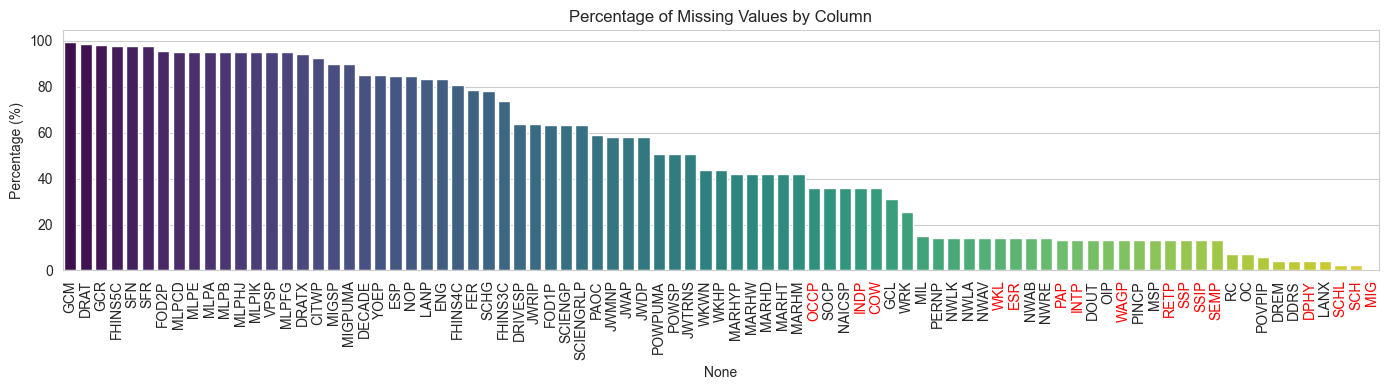

In [9]:
# Check missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0]

missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})

# Sort by percentage descending
missing_df = missing_df.sort_values('Percentage', ascending=False)

# Plot
plt.figure(figsize=(14, 4))
ax = sns.barplot(
    x=missing_df.index,
    y=missing_df['Percentage'],
    palette='viridis'
)

plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)

# Highlight selected features from 2.1 Feature Selection
keep_cols = ['WAGP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP', 'ESR', 'COW', 'WKL', 'OCCP', 'INDP', 'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP','SCHL', 'SCH', 'DIS', 'DEAR', 'DEYE', 'DPHY', 'STATE', 'PUMA']

for label in ax.get_xticklabels():
    if label.get_text() in keep_cols:
        label.set_color('red')

plt.tight_layout()
plt.show()

*Note:* Features highlighted in **red** indicate variables retained for modelling during the feature selection step (Section 2.1). While the dataset contains a substantial number of missing values overall, the selected features have manageable levels of missingness, which are addressed in the data cleaning process (Section 2.2).

### 1.3 Health Insurance Combinations & Class Imbalances *(optional)*

The PUMS dataset contains seven binary health insurance indicators (`HINS1`–`HINS7`) representing different types of coverage, which can occur in *various combinations* for each individual. We analyze the most common combinations of these indicators (1) to understand how insurance coverage is structured in the data and (2) to gain an initial understanding of potential class imbalances relevant for the subsequent modelling task.

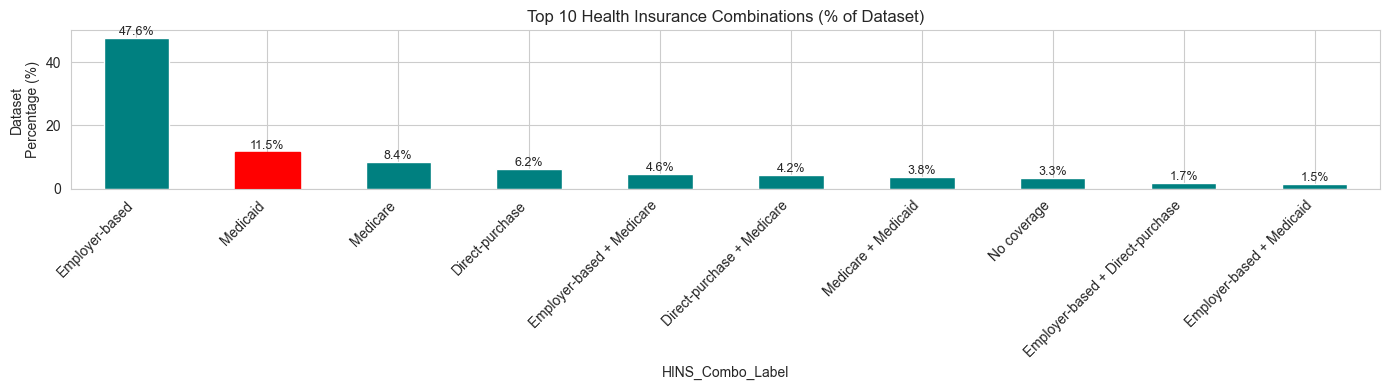

In [10]:
# Define HINS labels
hins_labels = {
    'HINS1': 'Employer-based',
    'HINS2': 'Direct-purchase',
    'HINS3': 'Medicare',
    'HINS4': 'Medicaid',
    'HINS5': 'Tricare/VA',
    'HINS6': 'Other public',
    'HINS7': 'No coverage'
}

# Identify health insurance indicator columns
hins_cols = sorted([c for c in df_raw.columns if c.startswith('HINS') and len(c) == 5])

# Create a readable combination label per individual
def map_hins_combo(row):
    combo_parts = []
    for col in hins_cols:
        if row[col] == 1:
            combo_parts.append(hins_labels.get(col, col))
    return ' + '.join(combo_parts) if combo_parts else 'No coverage'

df_raw['HINS_Combo_Label'] = df_raw.apply(map_hins_combo, axis=1)

# Get most frequent combinations
top_combos = (
    df_raw['HINS_Combo_Label']
    .value_counts(normalize=True)
    .head(10) * 100
)

# Plot top combinations
plt.figure(figsize=(14, 4))
ax = top_combos.plot(kind='bar', color='teal')

# Highlight Medicaid-only bar in red
for i, label in enumerate(top_combos.index):
    if label == 'Medicaid':
        ax.patches[i].set_color('red')

# Add percentage labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Top 10 Health Insurance Combinations (% of Dataset)')
plt.ylabel('Dataset\nPercentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Note:* Each bar represents a distinct and mutually exclusive insurance coverage group. This distribution helps us identify the proportion of individuals covered *exclusively* by Medicaid and understand potential class imbalances in the data.

### 1.4 Exploratory Feature Analysis *(optional)*

In this section, we analyze relationships between individual features and the target variable `only_medicaid`, which indicates whether a person is covered *exclusively* by Medicaid (based on the insurance indicator combinations discussed in Section 1.3). Using correlation analysis and mutual information, we gain insights into feature relevance that help guide feature selection decisions later in the modelling pipeline.

In [11]:
# Create target variable: only_medicaid (only for this analysis, later again defined in Section 2.3)
insurance_cols = ['HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7']

df_raw['only_medicaid'] = np.where(
    (df_raw['HINS4'] == 1) & df_raw[insurance_cols].eq(2).all(axis=1),
    1,
    0
)

**Correlation:** We compute the absolute correlation between numeric features and the target variable `only_medicaid` to identify features with strong linear relationships to Medicaid-only coverage.

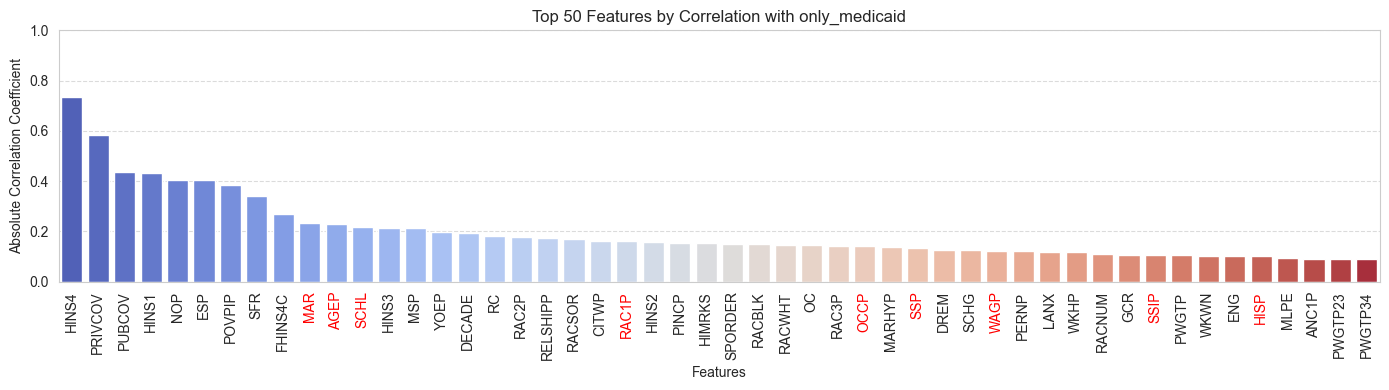

In [12]:
# Define numeric columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns

# Calculate correlation of all numeric features with only_medicaid
corr_with_target = (
    df_raw[numeric_cols]
    .corrwith(df_raw['only_medicaid'])
    .abs()
    .sort_values(ascending=False)
)

# Remove target itself from the results
corr_with_target = corr_with_target.drop('only_medicaid', errors='ignore')

# Convert to DataFrame
corr_df = pd.DataFrame(corr_with_target, columns=['Correlation Coefficient'])

# Get top 50 features
top_50 = corr_df.head(50)

# Plot
plt.figure(figsize=(14, 4))
ax = sns.barplot(
    x=top_50.index,
    y=top_50['Correlation Coefficient'],
    palette='coolwarm'
)

plt.title('Top 50 Features by Correlation with only_medicaid')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation Coefficient')
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

keep_set = set(keep_cols)
for label in ax.get_xticklabels():
    if label.get_text().strip() in keep_set:
        label.set_color('red')

plt.tight_layout()
plt.show()


*Note:* Some features show strong correlation with the target variable but are not included in the final modelling feature sets. Feature selection is guided by substantive and practical considerations and is discussed in more detail in Section 2.1 (Feature Selection).

**Mutual Information:** We calculate mutual information scores between features and `only_medicaid` to capture non-linear dependencies and rank features by their overall predictive relevance.

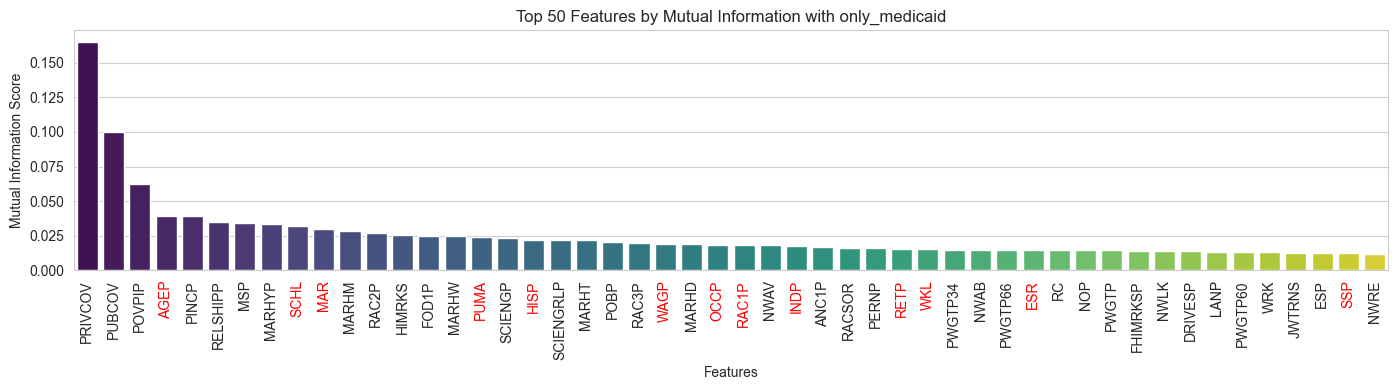

In [13]:
# Use a sample for speed
sample_df = df_raw.sample(min(5000, len(df_raw)), random_state=42).fillna(0)

# Define X and y for mutual information
drop_cols = ['only_medicaid'] + [c for c in sample_df.columns if c.startswith('HINS')]
X_mi = sample_df.select_dtypes(include=[np.number]).drop(columns=drop_cols, errors='ignore')
y_mi = sample_df['only_medicaid']

# Mutual information
mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

# Plot TOP 50 Mutual Information scores
plt.figure(figsize=(14, 4))
top_50_mi = mi_series.head(50)

ax = sns.barplot(x=top_50_mi.index, y=top_50_mi.values, palette='viridis')

plt.title('Top 50 Features by Mutual Information with only_medicaid')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=90)

# Highlight selected features
keep_set = set(keep_cols)
for label in ax.get_xticklabels():
    if label.get_text().strip() in keep_set:
        label.set_color('red')

plt.tight_layout()
plt.show()

*Note:* Some features show strong mutual information with the target variable but are not included in the final modelling feature sets. Feature selection is guided by substantive and practical considerations and is discussed in more detail in Section 2.1 (Feature Selection).

---

## 2. Data Cleaning and Feature Engineering

After exploring the initial dataset, we now transform the raw data into model-ready feature sets through a structured cleaning and engineering process.

*Section 2.1 reduces the dataset to only the features relevant for modelling, while Section 2.2 focuses on data cleaning, handling missing values, and ensuring data consistency. Section 2.3 constructs the target variable and engineers additional features to create a fully processed modelling dataframe. Finally, Section 2.4 generates three feature subsets for comparison: a **Statistical (Baseline)** set with all features for upper-bound performance, a **Realistic** set with only publicly accessible or inferable information, and a **Business** set containing richer attributes an insurer would already know. These subsets help evaluate how different levels of information availability influence model performance and applicability.*


### 2.1 Feature Selection

First, we filter the dataset to retain only the most relevant features for our analysis, grouped by domain. This step reduces dimensionality and focuses the model on impactful variables. The features in the Target Group will later be used to engineer _one_ target variable (`only_medicaid`).

**Kept Features:**
- **Group 1 (Income & Affordability):** `WAGP`, `SEMP`, `INTP`, `RETP`, `SSP`, `SSIP`, `PAP`
- **Group 2 (Employment Quality):** `ESR`, `COW`, `WKL`, `OCCP`, `INDP`
- **Group 3 (Demographics):** `AGEP`, `SEX`, `MAR`, `MIG`, `NATIVITY`, `RAC1P`, `HISP`
- **Group 4 (Education):** `SCHL`, `SCH`
- **Group 5 (Health & Disability):** `DIS`, `DEAR`, `DEYE`, `DPHY`
- **Group 6 (Geography):** `STATE`, `PUMA`
- **Target Group (Health Insurance Indicators):** `HINS4`, `HINS1`, `HINS2`, `HINS3`, `HINS5`, `HINS6`, `HINS7`

In [14]:
keep_cols = [
    # Income & Affordability
    'WAGP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP',
    # Employment Quality
    'ESR', 'COW', 'WKL', 'OCCP', 'INDP',
    # Demographics
    'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP',
    # Education
    'SCHL', 'SCH',
    # Health & Disability
    'DIS', 'DEAR', 'DEYE', 'DPHY',
    # Geography
    'STATE', 'PUMA',
    # Health Insurance Indicators
    'HINS4', 'HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7',
]

existing_cols = [c for c in keep_cols if c in df_raw.columns]
dropped_cols = len(df_raw.columns) - len(existing_cols)

df_2_1 = df_raw[existing_cols]
print(f"Retained {len(existing_cols)} features. Dropped {dropped_cols} features.")
display(df_2_1.head(3))

Retained 34 features. Dropped 254 features.


,WAGP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,WKL,...,DPHY,STATE,PUMA,HINS4,HINS1,HINS2,HINS3,HINS5,HINS6,HINS7
0,125000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,...,2.0,9,20500,2,1,2,2,2,2,2
1,9400.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1.0,...,2.0,9,20603,2,1,2,2,2,2,2
2,0.0,0.0,0.0,2400.0,18600.0,0.0,0.0,6.0,NaN,3.0,...,1.0,9,20603,1,2,2,1,2,2,2


### 2.2 Data Cleaning

In this step, we further reduce the dataset to include only individuals between the ages of 18 and 65, as this is the relevant population for our analysis.

In [15]:
df_2_2 = df_2_1.copy()

if 'AGEP' in df_2_2.columns:
    print("Filtering Age (18-65)...")
    initial_count = len(df_2_2)
    df_2_2 = df_2_2[(df_2_2['AGEP'] >= 18) & (df_2_2['AGEP'] <= 65)]
    print(f"Removed {initial_count - len(df_2_2)} rows outside age range.")

Filtering Age (18-65)...
Removed 63362 rows outside age range.


We then apply imputations for the features `OCCP` (Occupation Code), `INDP` (Industry Code), and `COW` (Class of Worker). If any of these values are missing, we impute them with the corresponding code for "unemployed."

In [16]:
# Imputations for OCCP and INDP
for col in ['OCCP', 'INDP']:
    if col in df_2_1.columns:
            df_2_2[col] = df_2_2[col].fillna(9920)
            print(f"Imputed {col} with 9920")

# Imputations for COW
if 'COW' in df_2_2.columns:
    df_2_2['COW'] = df_2_2['COW'].fillna(9)
    print("Imputed COW with 9")

Imputed OCCP with 9920
Imputed INDP with 9920
Imputed COW with 9


Lastly, we perform a final check for remaining missing values to ensure data consistency before moving on to feature engineering.

In [17]:
missing = df_2_2.isnull().sum()
missing = missing[missing > 0]

if not missing.empty:
    print(f"\nFound {len(missing)} columns with missing values.")
    missing_pct = (missing / len(df_2_2)) * 100
    missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
    print(missing_report.sort_values('Percentage', ascending=False).head(10))
else:
    print("\nNo missing values found.")

print("Data Cleaning Completed.")


No missing values found.
Data Cleaning Completed.


### 2.3 Feature Engineering
We create a new dataframe with engineered features based on business logic. This involves binning continuous variables and creating simplified categories.

**Target Variable:** First, we create the target variable `only_medicaid` based on insurance indicators and then drop all original `HINS` columns. We want to predict, whether an individual is insured *only* with Medicaid, and no other insurance type.

In [18]:
df_2_3 = df_2_2.copy()

insurance = ["HINS1","HINS2","HINS3","HINS5","HINS6","HINS7"]

df_2_3["only_medicaid"] = np.where(
    (df_2_3["HINS4"] == 1) & df_2_3[insurance].eq(2).all(axis=1),
    1,
    0
)

df_2_3 = df_2_3.drop(columns=[c for c in df_2_3.columns if c.startswith("HINS")])

target = 'only_medicaid' # save as variable 'target' for function calls later

**Group 1 (Income & Affordability):** We introduce the feature `income_group` by binning continuous income, add the boolean variable `has_wage_income`, create `income_source_count` to capture how many income sources an individual has, and add `has_self_employment` to indicate self-employment income.

In [19]:
# income_group
if 'WAGP' in df_2_3.columns:
    bins = [-1, 15000, 30000, 50000, 75000, np.inf]
    labels = ['Very_Low', 'Low', 'Medium', 'High', 'Very_High']
    df_2_3['income_group'] = pd.cut(df_2_3['WAGP'], bins=bins, labels=labels)

# has_wage_income
if 'WAGP' in df_2_3.columns:
    df_2_3['has_wage_income'] = (df_2_3['WAGP'] > 0).astype(int)
    
# income_source_count
income_cols = ['WAGP','SEMP','INTP','RETP','SSP','SSIP','PAP']
avail_inc_cols = [c for c in income_cols if c in df_2_3.columns]
if avail_inc_cols:
    df_2_3['income_source_count'] = (df_2_3[avail_inc_cols] > 0).sum(axis=1)

# has_self_employment
if 'SEMP' in df_2_3.columns:
    df_2_3['has_self_employment'] = (df_2_3['SEMP'] > 0).astype(int)

**Group 2 (Employment Quality):** We create `employment_status_simple` to group detailed labor-force categories into broader employment states, introduce `employer_type` to classify the type of employer, and derive `OCCP_2digit` and `INDP_2digit` to convert detailed occupation and industry codes into more general two-digit categories.

In [20]:
# employment_status_simple
if 'ESR' in df_2_3.columns:
    esr_mapping = {
        1: 'Employed', 2: 'Employed',
        3: 'Unemployed',
        4: 'Not_in_labor_force', 5: 'Not_in_labor_force', 6: 'Not_in_labor_force'
    }
    df_2_3['employment_status_simple'] = df_2_3['ESR'].map(esr_mapping).fillna('Not_in_labor_force')

# employer_type
if 'COW' in df_2_3.columns:
    cow_mapping = {
        1: 'Private', 2: 'Private',
        3: 'Government', 4: 'Government', 5: 'Government',
        6: 'Self_employed', 7: 'Self_employed',
        8: 'Unpaid', 9: 'Unpaid'
    }
    df_2_3['employer_type'] = df_2_3['COW'].map(cow_mapping).fillna('Unknown')

# OCCP/INDP 2-digit conversion: Create derived features needed for selection
if 'OCCP' in df_2_3.columns:
    df_2_3['OCCP_2digit'] = df_2_3['OCCP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]
if 'INDP' in df_2_3.columns:
    df_2_3['INDP_2digit'] = df_2_3['INDP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]

**Group 3 (Demographics):** We create the feature `age_group` by binning individuals into age brackets and introduce `marital_status_simple` to consolidate detailed marital categories into broader, more informative groups.

In [21]:
# age_group
if 'AGEP' in df_2_3.columns:
    bins = [17, 25, 35, 45, 55, 65]
    labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
    df_2_3['age_group'] = pd.cut(df_2_3['AGEP'], bins=bins, labels=labels)

# marital_status_simple
if 'MAR' in df_2_3.columns:
    mar_mapping = {
        1: 'Married',
        2: 'Divorced_Separated', 3: 'Divorced_Separated', 4: 'Divorced_Separated',
        5: 'Never_married'
    }
    df_2_3['marital_status_simple'] = df_2_3['MAR'].map(mar_mapping).fillna('Unknown')

**Group 4 (Education):** We create `education_level` by mapping detailed schooling codes into broader education categories and add `currently_enrolled` to indicate whether an individual is actively enrolled in school.

In [22]:
# education_level
if 'SCHL' in df_2_3.columns:
    def map_education(val):
        if pd.isna(val) or val == 0: return 'Unknown'
        if val <= 15: return 'Less_than_HS'
        if val <= 17: return 'HS_diploma'
        if val <= 20: return 'Some_college'
        if val == 21: return 'Bachelors'
        return 'Graduate'
    df_2_3['education_level'] = df_2_3['SCHL'].apply(map_education)

# currently_enrolled
if 'SCH' in df_2_3.columns:
    df_2_3['currently_enrolled'] = df_2_3['SCH'].isin([2, 3]).astype(int)

**Group 5 (Health & Disability):** We create the feature `has_any_disability` to indicate whether an individual reports any disability across the available disability-related indicators.

In [23]:
# has_any_disability
dis_cols = ['DIS', 'DEAR', 'DEYE', 'DPHY']
avail_dis_cols = [c for c in dis_cols if c in df_2_3.columns]
if avail_dis_cols:
    df_2_3['has_any_disability'] = (df_2_3[avail_dis_cols] == 1).any(axis=1).astype(int)

**Group 6 (Geography):** We standardize geographic information by creating the feature `STATE` when only the shorter code `ST` is available.

In [24]:
if 'ST' in df_2_3.columns and 'STATE' not in df_2_3.columns:
    df_2_3['STATE'] = df_2_3['ST']

print("Feature Engineering Completed.")
display(df_2_3.head(3))

Feature Engineering Completed.


,WAGP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,WKL,...,has_self_employment,employment_status_simple,employer_type,OCCP_2digit,INDP_2digit,age_group,marital_status_simple,education_level,currently_enrolled,has_any_disability
0,125000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,...,0,Employed,Private,27,78,36-45,Married,Graduate,0,0
1,9400.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1.0,...,0,Not_in_labor_force,Private,44,85,18-25,Never_married,Some_college,1,0
3,2600.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,2.0,1.0,...,0,Not_in_labor_force,Private,46,86,18-25,Never_married,Some_college,1,0


### 2.4 Create Feature Sets
We create 6 datasets with different feature sets for modeling to evaluate performance across different levels of data availability and complexity.

**Feature Sets:**
1. **Statistical (Baseline):** Includes all features to benchmark the model's best possible performance under ideal conditions.  
2. **Realistic:** Contains only features that could plausibly be obtained from publicly accessible or online-inferred data sources (e.g., demographics, social media signals).  
3. **Business:** Includes richer customer information available to an insurer through existing business relationships.
4.  **PCA Statistical:** The Statistical set reduced using Principal Component Analysis (PCA).
5.  **PCA Realistic:** The Realistic set reduced using PCA.
6.  **PCA Business:** The Business set reduced using PCA.

In [25]:
# Statistical (Baseline) Features - use all original columns from 2.1, excluding the new engineered ones from 2.3
engineered_cols = [
    'income_group', 'has_wage_income', 'income_source_count', 'poverty_band', 
    'has_self_employment', 'employment_status_simple', 'employer_type', 
    'age_group', 'marital_status_simple', 'education_level', 'currently_enrolled', 
    'has_any_disability'
]

# Realistic Feature Set
cols_realistic = [
    'income_group', 'has_wage_income', 'has_self_employment',
    'employment_status_simple', 'employer_type',
    'SEX', 'age_group', 'marital_status_simple',
    'education_level', 'currently_enrolled',
    'STATE', 'PUMA'
]

# Business Features Set
cols_business = [
    'WAGP', 'SEMP', 'income_source_count', 'has_wage_income', 'has_self_employment',
    'WKL', 'OCCP_2digit', 'INDP_2digit', 'employment_status_simple', 'employer_type',
    'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP', 'age_group', 'marital_status_simple',
    'education_level', 'currently_enrolled', 'has_any_disability',
    'STATE', 'PUMA'
]

We define two helper functions, `preprocess_set()` and `apply_pca()`, to streamline repeated preprocessing steps across all feature sets.

In `preprocess_set()`, we (1) select all valid columns from the specified feature list, (2) separate the target variable, (3) identify and one-hot encode categorical features, (4) standardize all encoded features, and (5) remove highly collinear variables based on a correlation threshold before returning the final preprocessed feature matrix and target vector.

In [26]:
def preprocess_set(df_subset, col_list, set_name):
    # Filter columns that exist in the dataframe
    valid_cols = [c for c in col_list if c in df_subset.columns]

        
    X = df_subset[valid_cols].copy()
    y = df_subset[target]
    
    # Identify types
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
            
    # One-Hot Encoding
    X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    
    # Standard Scaling
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)
    
    corr_matrix = X_scaled.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_final = X_scaled.drop(columns=to_drop)
    print(f"Dropped {len(to_drop)} collinear features: {to_drop}")
        
    return X_final, y

In `apply_pca()`, we (1) validate that the input matrix is non-empty, (2) adjust the requested number of components if it exceeds allowable dimensions, (3) apply PCA to reduce the feature space while preserving at least 95% of the variance (or the specified threshold), and (4) return the transformed components as a new DataFrame, falling back to the original data if PCA fails.

In [ ]:
def apply_pca(X, n_components=0.95):
    if X.empty or X.shape[1] == 0:
        print("  -> Warning: Input to PCA is empty. Returning empty DataFrame.")
        return pd.DataFrame(index=X.index)
        
    # Ensure n_components is valid
    n_samples, n_features = X.shape
    if n_components > min(n_samples, n_features):
            n_components = min(n_samples, n_features)
            
    pca = PCA(n_components=n_components)
    try:
        X_pca = pca.fit_transform(X)
        cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
        return pd.DataFrame(X_pca, columns=cols, index=X.index)
    except Exception as e:
        print(f"  -> PCA Failed: {e}")
        return X # Fallback to original if PCA fails

We now generate six feature sets using `create_feature_sets()`: three base sets (Statistical, Realistic, and Business) that reflect different levels of information availability, along with their corresponding PCA-reduced versions. Each set is preprocessed consistently and stored in the `feature_sets` dictionary to enable systematic comparison during model training.

In [28]:
def create_feature_sets(df_input, cols_realistic, cols_business, engineered_cols):
    df = df_input.copy()
    
    if target not in df.columns:
        print(f"Error: Target {target} not found.")
        return {}

    cols_statistical = [c for c in df.columns if c not in engineered_cols and c != target]
    feature_sets = {}

    # 1. Statistical
    print("\nGenerating Set 1: Statistical (Baseline)...")
    X_stat, y_stat = preprocess_set(df, cols_statistical, "Statistical")
    feature_sets['Statistical'] = (X_stat, y_stat)

    # 2. Realistic
    print("\nGenerating Set 2: Realistic...")
    X_real, y_real = preprocess_set(df, cols_realistic, "Realistic")
    feature_sets['Realistic'] = (X_real, y_real)

    # 3. Business
    print("\nGenerating Set 3: Business...")
    X_bus, y_bus = preprocess_set(df, cols_business, "Business")
    feature_sets['Business'] = (X_bus, y_bus)

    # 4. PCA Statistical
    print("\nGenerating Set 4: PCA Statistical...")
    X_pca_stat = apply_pca(X_stat)
    feature_sets['PCA_Statistical'] = (X_pca_stat, y_stat)

    # 5. PCA Realistic
    print("\nGenerating Set 5: PCA Realistic...")
    X_pca_real = apply_pca(X_real)
    feature_sets['PCA_Realistic'] = (X_pca_real, y_real)

    # 6. PCA Business
    print("\nGenerating Set 6: PCA Business...")
    X_pca_bus = apply_pca(X_bus)
    feature_sets['PCA_Business'] = (X_pca_bus, y_bus)

    return feature_sets


if 'df_2_3' in locals():
    feature_sets = create_feature_sets(df_2_3, cols_realistic, cols_business, engineered_cols) # We use df_2_3 (Engineered, Pre-Encoding) as the base to allow for specific feature selection
    
    # Display shapes
    print("\nSummary of Feature Sets:")
    for name, (X, y) in feature_sets.items():
        print(f" - {name:<15}: {X.shape[1]} features, {X.shape[0]} rows")


Generating Set 1: Statistical (Baseline)...
Dropped 1 collinear features: ['INDP_2digit_99']

Generating Set 2: Realistic...
Dropped 0 collinear features: []

Generating Set 3: Business...
Dropped 2 collinear features: ['INDP_2digit_99', 'employer_type_Unpaid']

Generating Set 4: PCA Statistical...

Generating Set 5: PCA Realistic...

Generating Set 6: PCA Business...

Summary of Feature Sets:
 - Statistical    : 219 features, 95533 rows
 - Realistic      : 25 features, 95533 rows
 - Business       : 223 features, 95533 rows
 - PCA_Statistical: 146 features, 95533 rows
 - PCA_Realistic  : 13 features, 95533 rows
 - PCA_Business   : 146 features, 95533 rows


---

## 3. Modelling
*Instructions: Describe the modeling techniques used (Logistic Regression, Random Forest, etc.) and the feature engineering process.*

### 3.1 Data Splitting
We split the dataset into training, validation, and test sets with 70%, 15%, and 15% proportions, respectively. Stratified sampling is used to maintain the target variable distribution across splits.

randomize!

In [29]:
def split_dataset(X, y, test_size=0.15, val_size=0.15, random_state=42):
    """
    Splits data into Train, Validation, and Test sets with Stratification.
    """
    temp_size = val_size + test_size
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=temp_size, stratify=y, random_state=random_state
    )
    
    val_split_ratio = val_size / temp_size
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - val_split_ratio), stratify=y_temp, random_state=random_state
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test

data_splits = {}

if 'feature_sets' in locals():
    for set_name, (X, y) in feature_sets.items():
        print(f"\nSplitting {set_name} Set")
        X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
        
        data_splits[set_name] = {
            'X_train': X_train, 'y_train': y_train,
            'X_val': X_val, 'y_val': y_val,
            'X_test': X_test, 'y_test': y_test
        }
        
        print(f"  Train: {X_train.shape[0]} rows ({len(y_train)/len(y):.1%})")
        print(f"  Val  : {X_val.shape[0]} rows ({len(y_val)/len(y):.1%})")
        print(f"  Test : {X_test.shape[0]} rows ({len(y_test)/len(y):.1%})")
else:
    print("Error: feature_sets not found. Please run Section 3.4 first.")


Splitting Statistical Set
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)

Splitting Realistic Set
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)

Splitting Business Set
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)

Splitting PCA_Statistical Set
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)

Splitting PCA_Realistic Set
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)

Splitting PCA_Business Set
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)


In [30]:
# !pip install imbalanced-learn  # Uncomment if you need to install it
from imblearn.over_sampling import SMOTE

print("Applying SMOTE to Training Sets...")

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        print(f"\nProcessing {set_name}...")
        
        X_train_orig = splits['X_train']
        y_train_orig = splits['y_train']
        
        # Initialize SMOTE
        smote = SMOTE(random_state=42)
        
        # Fit and resample ONLY the training data
        X_train_res, y_train_res = smote.fit_resample(X_train_orig, y_train_orig)
        
        # Update the dictionary with the new balanced training data
        data_splits[set_name]['X_train'] = X_train_res
        data_splits[set_name]['y_train'] = y_train_res
        
        # Print stats as Percentages
        orig_dist = y_train_orig.value_counts(normalize=True).mul(100).round(2).to_dict()
        res_dist = y_train_res.value_counts(normalize=True).mul(100).round(2).to_dict()
        
        # Print stats
        print(f"  Original class dist : {orig_dist}")
        print(f"  Resampled class dist: {res_dist}")
        print(f"  New Train Shape     : {X_train_res.shape}")

else:
    print("Error: data_splits not found. Run Section 3.1 first.")

Applying SMOTE to Training Sets...

Processing Statistical...
  Original class dist : {0: 87.47, 1: 12.53}
  Resampled class dist: {0: 50.0, 1: 50.0}
  New Train Shape     : (116982, 219)

Processing Realistic...
  Original class dist : {0: 87.47, 1: 12.53}
  Resampled class dist: {0: 50.0, 1: 50.0}
  New Train Shape     : (116982, 25)

Processing Business...
  Original class dist : {0: 87.47, 1: 12.53}
  Resampled class dist: {0: 50.0, 1: 50.0}
  New Train Shape     : (116982, 223)

Processing PCA_Statistical...
  Original class dist : {0: 87.47, 1: 12.53}
  Resampled class dist: {0: 50.0, 1: 50.0}
  New Train Shape     : (116982, 146)

Processing PCA_Realistic...
  Original class dist : {0: 87.47, 1: 12.53}
  Resampled class dist: {0: 50.0, 1: 50.0}
  New Train Shape     : (116982, 13)

Processing PCA_Business...
  Original class dist : {0: 87.47, 1: 12.53}
  Resampled class dist: {0: 50.0, 1: 50.0}
  New Train Shape     : (116982, 146)


### 3.2 Model Training


In [28]:
def train_and_tune(model, param_grid, X_train, y_train, X_val, y_val, model_name, dataset_name):
    print(f"Training {model_name} on {dataset_name}...")
    
    start_time = time.time()
    
    # Use GridSearchCV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=3,
        scoring='average_precision',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    # Evaluate on Validation Set
    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, "predict_proba") else y_pred
    
    val_accuracy = accuracy_score(y_val, y_pred)
    val_pr_auc = average_precision_score(y_val, y_prob)
    val_roc_auc = roc_auc_score(y_val, y_prob)

    # Evaluate on Training Set
    y_train_pred = best_model.predict(X_train)
    y_train_prob = best_model.predict_proba(X_train)[:, 1] if hasattr(best_model, "predict_proba") else y_train_pred
    train_pr_auc = average_precision_score(y_train, y_train_prob)
    
    print(f"  -> Best Params: {best_params}")
    print(f"  -> Val PR-AUC: {val_pr_auc:.4f}")
    print(f"  -> Train PR-AUC: {train_pr_auc:.4f}")
    print(f"  -> Training Time: {training_time:.2f} seconds")
    
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Best_Params': best_params,
        'Val_Accuracy': val_accuracy,
        'Val_PR_AUC': val_pr_auc,
        'Val_ROC_AUC': val_roc_auc,
        'Train_PR_AUC': train_pr_auc,
        'Training_Time': training_time,
        'Model_Instance': best_model
    }

# Store all results
all_results = []

#### 3.2.1 Logistic Regression
We train Logistic Regression models across all feature sets, tuning regularization strength (`C`) and penalty type.

In [29]:
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            LogisticRegression(random_state=42),
            lr_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "LogisticRegression", set_name
        )
        all_results.append(res)

Training LogisticRegression on Statistical...
  -> Best Params: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3869
  -> Train PR-AUC: 0.8222
  -> Training Time: 17.85 seconds
Training LogisticRegression on Realistic...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3995
  -> Train PR-AUC: 0.8218
  -> Training Time: 5.82 seconds
Training LogisticRegression on Business...
  -> Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.4061
  -> Train PR-AUC: 0.8252
  -> Training Time: 15.20 seconds
Training LogisticRegression on PCA_Statistical...
  -> Best Params: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3481
  -> Train PR-AUC: 0.7995
  -> Training Time: 16.87 seconds
Training LogisticRegression on PCA_Realistic...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3

#### 3.2.2 Random Forest
We train Random Forest models, tuning the number of trees (`n_estimators`) and maximum depth (`max_depth`) to control overfitting.

In [ ]:
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            RandomForestClassifier(random_state=42),
            rf_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "RandomForest", set_name
        )
        all_results.append(res)

Training RandomForest on Statistical...
  -> Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val PR-AUC: 0.5237
  -> Train PR-AUC: 0.9896
  -> Training Time: 86.06 seconds
Training RandomForest on Realistic...
  -> Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val PR-AUC: 0.4234
  -> Train PR-AUC: 0.9826
  -> Training Time: 33.03 seconds
Training RandomForest on Business...
  -> Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val PR-AUC: 0.4998
  -> Train PR-AUC: 0.9925
  -> Training Time: 125.54 seconds
Training RandomForest on PCA_Statistical...


#### 3.2.3 XGBoost
We train XGBoost models, tuning learning rate, max depth, and the number of estimators. XGBoost is known for its efficiency and performance on structured data.

In [ ]:
xgb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
    'eval_metric': ['logloss'],
    # GPU Support
    'tree_method': ['hist'], 
    'device': ['cuda']
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            XGBClassifier(use_label_encoder=False, random_state=42),
            xgb_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "XGBoost", set_name
        )
        all_results.append(res)

Training XGBoost on Statistical...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'tree_method': 'hist'}
  -> Val PR-AUC: 0.5006
  -> Train PR-AUC: 0.9833
  -> Training Time: 24.78 seconds
Training XGBoost on Realistic...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'tree_method': 'hist'}
  -> Val PR-AUC: 0.4327
  -> Train PR-AUC: 0.9630
  -> Training Time: 3.89 seconds
Training XGBoost on Business...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'tree_method': 'hist'}
  -> Val PR-AUC: 0.4647
  -> Train PR-AUC: 0.9832
  -> Training Time: 24.70 seconds
Training XGBoost on PCA_Statistical...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'tree_method': 'hist'}
  -> Val PR-AUC: 0.4403
  -> T

#### 3.2.4 LightGBM
We train LightGBM models, tuning the number of leaves and learning rate. LightGBM is often faster than XGBoost and handles large datasets well.

In [ ]:
import re

lgbm_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50],
    # GPU Support (Requires GPU-enabled LightGBM installation)
    'device': ['gpu'] 
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        # LightGBM requires clean column names (no special characters)
        X_train_clean = splits['X_train'].copy()
        X_val_clean = splits['X_val'].copy()
        
        # Rename columns using regex to replace non-alphanumeric chars with underscore
        X_train_clean.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in X_train_clean.columns]
        X_val_clean.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in X_val_clean.columns]
        
        try:
            res = train_and_tune(
                LGBMClassifier(random_state=42, verbose=-1),
                lgbm_params,
                X_train_clean, splits['y_train'],
                X_val_clean, splits['y_val'],
                "LightGBM", set_name
            )
            all_results.append(res)
        except Exception as e:
            print(f"LightGBM GPU training failed for {set_name}. Falling back to CPU. Error: {e}")
            # Fallback to CPU
            lgbm_params_cpu = lgbm_params.copy()
            del lgbm_params_cpu['device']
            res = train_and_tune(
                LGBMClassifier(random_state=42, verbose=-1),
                lgbm_params_cpu,
                X_train_clean, splits['y_train'],
                X_val_clean, splits['y_val'],
                "LightGBM", set_name
            )
            all_results.append(res)

Training LightGBM on Statistical...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 50}
  -> Val PR-AUC: 0.5288
  -> Train PR-AUC: 0.6837
  -> Training Time: 82.68 seconds
Training LightGBM on Realistic...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 50}
  -> Val PR-AUC: 0.4579
  -> Train PR-AUC: 0.5625
  -> Training Time: 69.03 seconds
Training LightGBM on Business...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 50}
  -> Val PR-AUC: 0.5010
  -> Train PR-AUC: 0.6431
  -> Training Time: 78.77 seconds
Training LightGBM on PCA_Statistical...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 50}
  -> Val PR-AUC: 0.4673
  -> Train PR-AUC: 0.7490
  -> Training Time: 87.92 seconds
Training LightGBM on PCA_Realistic...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 50, 'num_leaves': 31}

#### 3.2.5 Neural Network (MLP)
We train a Multi-Layer Perceptron (MLP), tuning the hidden layer sizes and activation functions to capture non-linear relationships.

In [ ]:
mlp_params = {
    # Keep architectures small and few
    'hidden_layer_sizes': [
        (64,),
        (64, 32),
        (128, 64)
    ],
    
    # Stick to one activation for speed and stability
    'activation': ['relu'],
    
    # Small set of regularization values
    'alpha': [1e-4, 1e-3],
    
    # Use adaptive to avoid wasting epochs
    'learning_rate': ['adaptive'],
    'learning_rate_init': [1e-3],
    
    # One or two batch sizes max
    'batch_size': [128],
    
    # Cap iterations; early stopping will usually halt earlier anyway
    'max_iter': [300]
}


if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            # Increase patience (n_iter_no_change) to avoid stopping too early
            MLPClassifier(random_state=42, early_stopping=True, n_iter_no_change=10),
            mlp_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "NeuralNetwork", set_name
        )
        all_results.append(res)

Training NeuralNetwork on Statistical...
  -> Best Params: {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 128, 'hidden_layer_sizes': (128, 64), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.4428
  -> Train PR-AUC: 0.5490
  -> Training Time: 29.28 seconds
Training NeuralNetwork on Realistic...
  -> Best Params: {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 128, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.4237
  -> Train PR-AUC: 0.4933
  -> Training Time: 14.30 seconds
Training NeuralNetwork on Business...
  -> Best Params: {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 128, 'hidden_layer_sizes': (64,), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.4302
  -> Train PR-AUC: 0.5703
  -> Training Time: 25.81 seconds
Training NeuralNetwork on PCA_Statistical...
  -> Best Params: {'activation': 'r

### 3.3 Model Comparison
We aggregate the results from all models and feature sets to identify the best performing combination based on Validation ROC-AUC.

Top 10 Models by Validation PR-AUC:


,Model,Dataset,Val_Accuracy,Val_PR_AUC
6,XGBoost,Statistical,0.874669,0.500581
8,XGBoost,Business,0.875087,0.464740
9,XGBoost,PCA_Statistical,0.766574,0.440335
7,XGBoost,Realistic,0.845429,0.432717
11,XGBoost,PCA_Business,0.773064,0.426599
10,XGBoost,PCA_Realistic,0.769016,0.412251
2,LogisticRegression,Business,0.739916,0.406098
1,LogisticRegression,Realistic,0.734543,0.399524
0,LogisticRegression,Statistical,0.731054,0.386908
5,LogisticRegression,PCA_Business,0.724215,0.374733


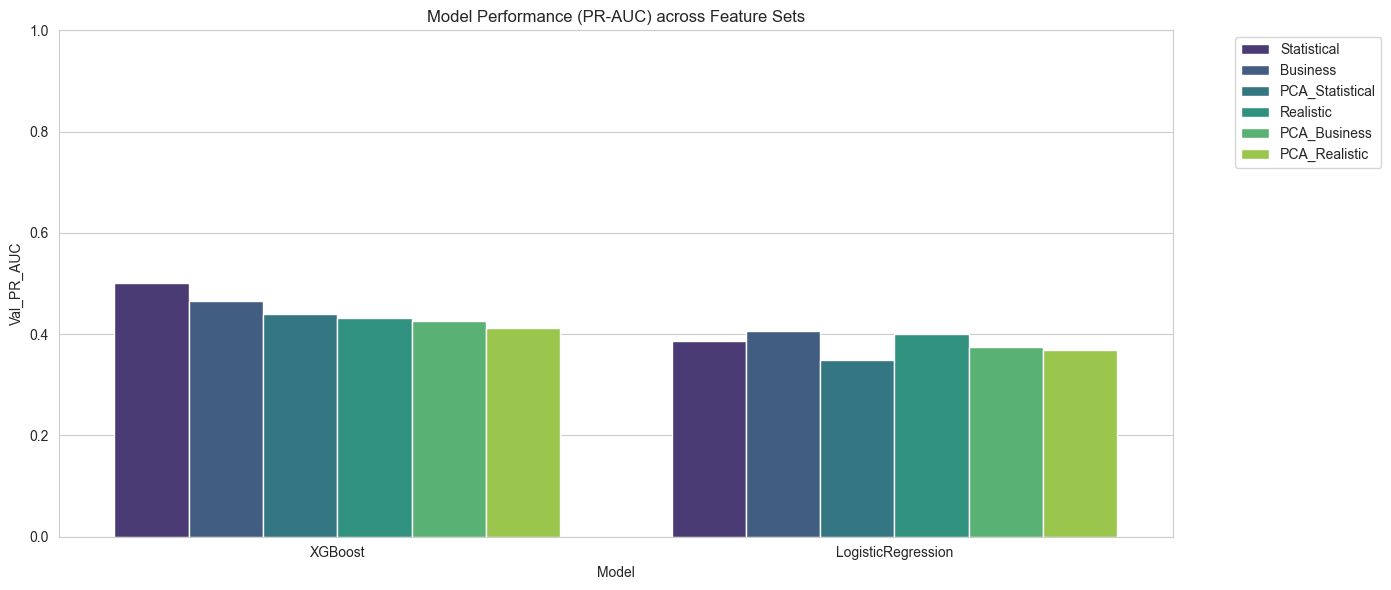

In [ ]:
# Create Results DataFrame
results_df = pd.DataFrame(all_results)

if not results_df.empty:
    # Sort by PR-AUC
    results_df = results_df.sort_values('Val_PR_AUC', ascending=False)
    
    print("Top 10 Models by Validation PR-AUC:")
    display(results_df[['Model', 'Dataset', 'Val_Accuracy', 'Val_PR_AUC']].head(10))
    
    # Visualization
    plt.figure(figsize=(14, 6))
    sns.barplot(data=results_df, x='Model', y='Val_PR_AUC', hue='Dataset', palette='viridis')
    plt.title('Model Performance (PR-AUC) across Feature Sets')
    plt.ylim(0, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No results to display.")

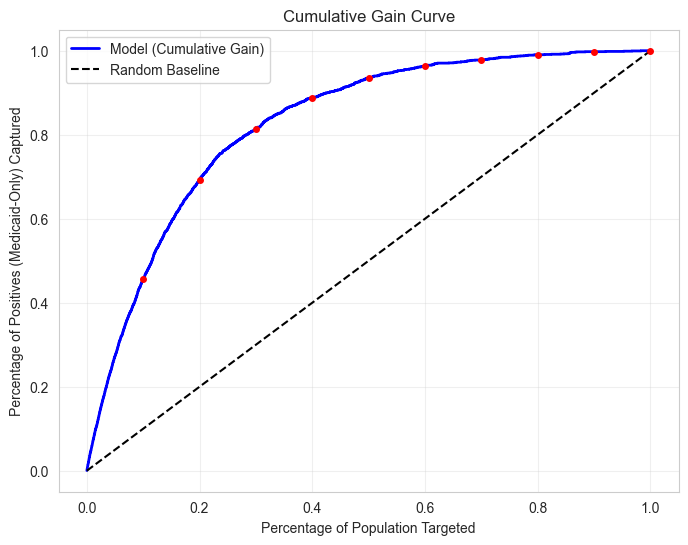

Gain at top 10% of population: 45.7% of all target cases captured.
Gain at top 20% of population: 69.2% of all target cases captured.


---

## 4. Evaluation
In this section, we analyze the performance of the 30 experimental combinations (5 Models $\times$ 6 Feature Sets). We start with a high-level overview to identify patterns, select the best performing model, and then perform a detailed evaluation on the held-out Test Set.

### 4.1 Performance Overview
We visualize the results to identify the top performers and understand how different feature sets impact model performance.

Top 5 Models by Validation ROC-AUC:


,Model,Dataset,Best_Params,Val_Accuracy,Val_PR_AUC,Val_ROC_AUC,Train_PR_AUC,Training_Time,Model_Instance
6,RandomForest,Statistical,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.894138,0.565044,0.871396,0.994965,33.635134,"(DecisionTreeClassifier(max_features='sqrt', m..."
18,LightGBM,Statistical,"{'device': 'gpu', 'learning_rate': 0.1, 'n_est...",0.892114,0.528800,0.869731,0.683657,82.681062,"LGBMClassifier(device='gpu', num_leaves=50, ra..."
12,XGBoost,Statistical,"{'device': 'cuda', 'eval_metric': 'logloss', '...",0.888904,0.510888,0.866552,0.620417,5.917762,"XGBClassifier(base_score=None, booster=None, c..."
20,LightGBM,Business,"{'device': 'gpu', 'learning_rate': 0.1, 'n_est...",0.887718,0.500956,0.865340,0.643071,78.772753,"LGBMClassifier(device='gpu', num_leaves=50, ra..."
8,RandomForest,Business,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.893231,0.545482,0.864315,0.989718,36.121026,"(DecisionTreeClassifier(max_features='sqrt', m..."


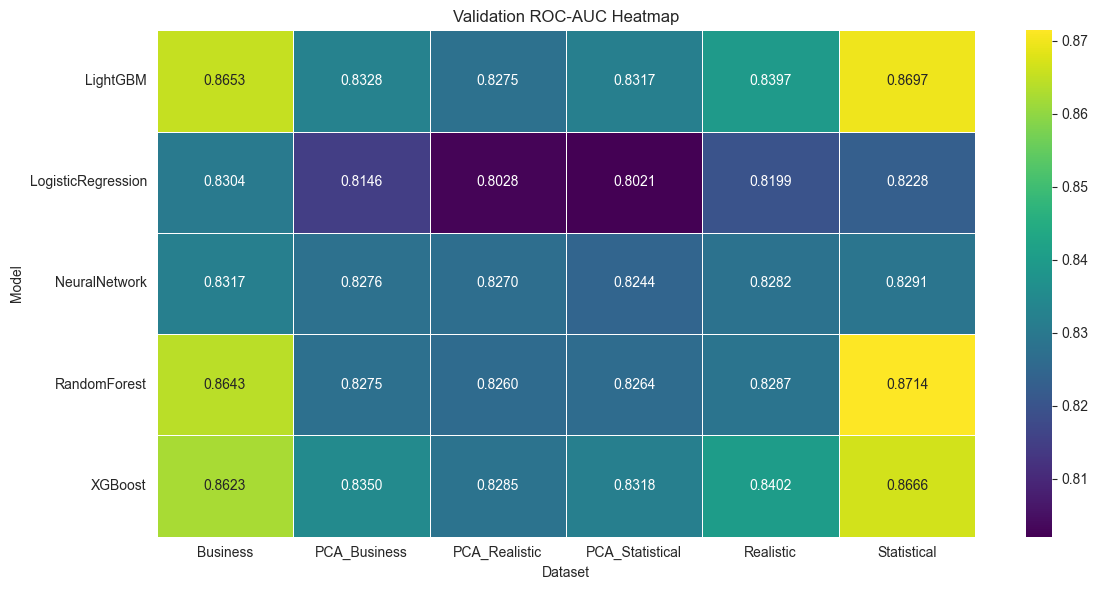

In [ ]:
if not results_df.empty:
    pivot_table = results_df.pivot(index='Model', columns='Dataset', values='Val_PR_AUC')
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap='viridis', linewidths=.5)
    plt.title('Validation PR-AUC Heatmap')
    plt.tight_layout()
    plt.show()

### 4.2 Cumulative Gain


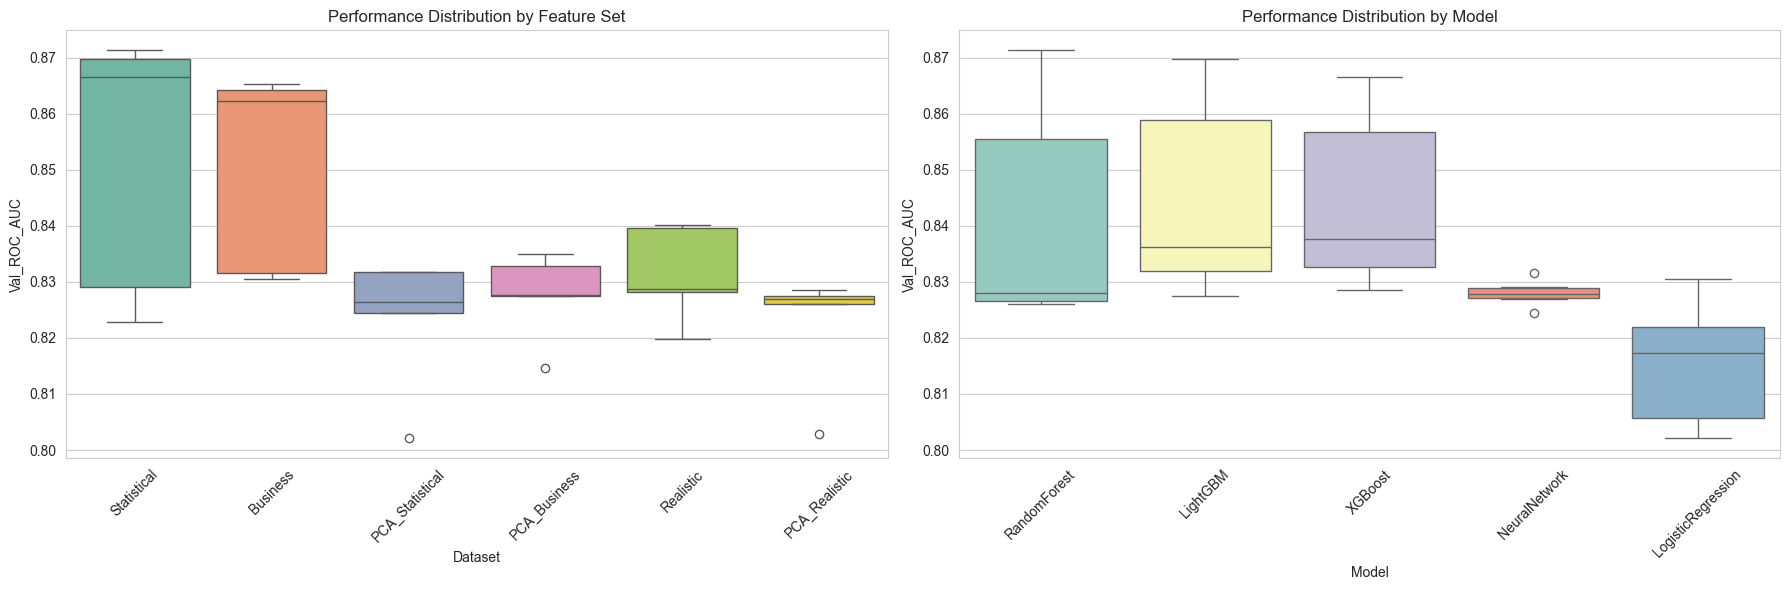

In [ ]:
# Calculate Cumulative Gain for ALL models
gain_results = []

if 'all_results' in locals() and all_results:
    print("Calculating Cumulative Gain for all models...")
    
    for res in all_results:
        model_name = res['Model']
        dataset_name = res['Dataset']
        model_instance = res['Model_Instance']
        
        # Get Test Data for this specific dataset
        if dataset_name in data_splits:
            X_test_curr = data_splits[dataset_name]['X_test']
            y_test_curr = data_splits[dataset_name]['y_test']
            
            if hasattr(model_instance, "predict_proba"):
                # Get probabilities
                y_prob = model_instance.predict_proba(X_test_curr)[:, 1]
                y_true = np.array(y_test_curr)

                # Sort by predicted probability (descending)
                sorted_indices = np.argsort(y_prob)[::-1]
                sorted_y_true = y_true[sorted_indices]

                # Calculate Cumulative Gain
                cum_positives = np.cumsum(sorted_y_true)
                total_positives = cum_positives[-1]
                
                if total_positives > 0:
                    cum_gain = cum_positives / total_positives
                    
                    # Get indices for 10%, 20%, 30%
                    n = len(cum_gain)
                    idx_10 = max(0, int(0.1 * n) - 1)
                    idx_20 = max(0, int(0.2 * n) - 1)
                    idx_30 = max(0, int(0.3 * n) - 1)
                    
                    gain_results.append({
                        'Model': model_name,
                        'Dataset': dataset_name,
                        'Gain@10%': cum_gain[idx_10] * 100,
                        'Gain@20%': cum_gain[idx_20] * 100,
                        'Gain@30%': cum_gain[idx_30] * 100
                    })

    # Create DataFrame
    if gain_results:
        gain_df = pd.DataFrame(gain_results)
        # Sort by Gain@10%
        gain_df = gain_df.sort_values('Gain@10%', ascending=False)
        
        print("\n--- Cumulative Gain Analysis (Percentage of Target Class Captured) ---")
        display(gain_df.round(2))
    else:
        print("No models supported predict_proba or no positive cases found.")
        
else:
    print("No results found in 'all_results'.")

In [ ]:
# Plot Cumulative Gain for Best Models per Dataset Type
if 'all_results' in locals() and all_results:
    plt.figure(figsize=(10, 6))
    
    # Define the datasets we want to compare
    target_datasets = ['Statistical', 'Business', 'Realistic']
    colors = {'Statistical': 'blue', 'Business': 'green', 'Realistic': 'orange'}
    
    # Find best model for each target dataset based on PR-AUC
    best_models = {}
    for ds in target_datasets:
        ds_results = [r for r in all_results if r['Dataset'] == ds]
        if ds_results:
            # Sort by PR-AUC and pick top 1
            best_model_entry = sorted(ds_results, key=lambda x: x['Val_PR_AUC'], reverse=True)[0]
            best_models[ds] = best_model_entry

    # Plot curves
    for ds_name, entry in best_models.items():
        model_instance = entry['Model_Instance']
        model_name = entry['Model']
        
        if dataset_name in data_splits:
            X_test_curr = data_splits[ds_name]['X_test']
            y_test_curr = data_splits[ds_name]['y_test']
            
            if hasattr(model_instance, "predict_proba"):
                y_prob = model_instance.predict_proba(X_test_curr)[:, 1]
                y_true = np.array(y_test_curr)
                
                # Sort
                sorted_indices = np.argsort(y_prob)[::-1]
                sorted_y_true = y_true[sorted_indices]
                
                # Cumulative Gain
                cum_positives = np.cumsum(sorted_y_true)
                total_positives = cum_positives[-1]
                
                if total_positives > 0:
                    cum_gain = cum_positives / total_positives
                    x_axis = np.arange(1, len(cum_gain) + 1) / len(cum_gain)
                    
                    # Plot line
                    label_str = f"{ds_name} (Best: {model_name})"
                    plt.plot(x_axis, cum_gain, label=label_str, color=colors.get(ds_name, 'gray'), linewidth=2)
                    
                    # Add markers at 10%, 20%, 30%
                    for pct in [0.1, 0.2, 0.3]:
                        idx = int(pct * len(cum_gain)) - 1
                        plt.plot(x_axis[idx], cum_gain[idx], marker='o', color=colors.get(ds_name, 'gray'), markersize=5)

    # Random Baseline
    plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
    
    plt.title('Cumulative Gain Curve: Best Models by Feature Set')
    plt.xlabel('Percentage of Population Targeted')
    plt.ylabel('Percentage of Positives Captured')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No results found.")

### 4.3 Best Model Evaluation on Test Set
We select the model with the highest Validation ROC-AUC and evaluate its performance on the held-out **Test Set** to confirm generalizability.

Best Model Selected: XGBoost on Statistical Set
Validation PR-AUC: 0.5006

--- Test Set Performance ---
Accuracy: 0.8816
ROC-AUC : 0.8743
PR-AUC  : 0.5416

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     12534
           1       0.53      0.54      0.53      1796

    accuracy                           0.88     14330
   macro avg       0.73      0.73      0.73     14330
weighted avg       0.88      0.88      0.88     14330



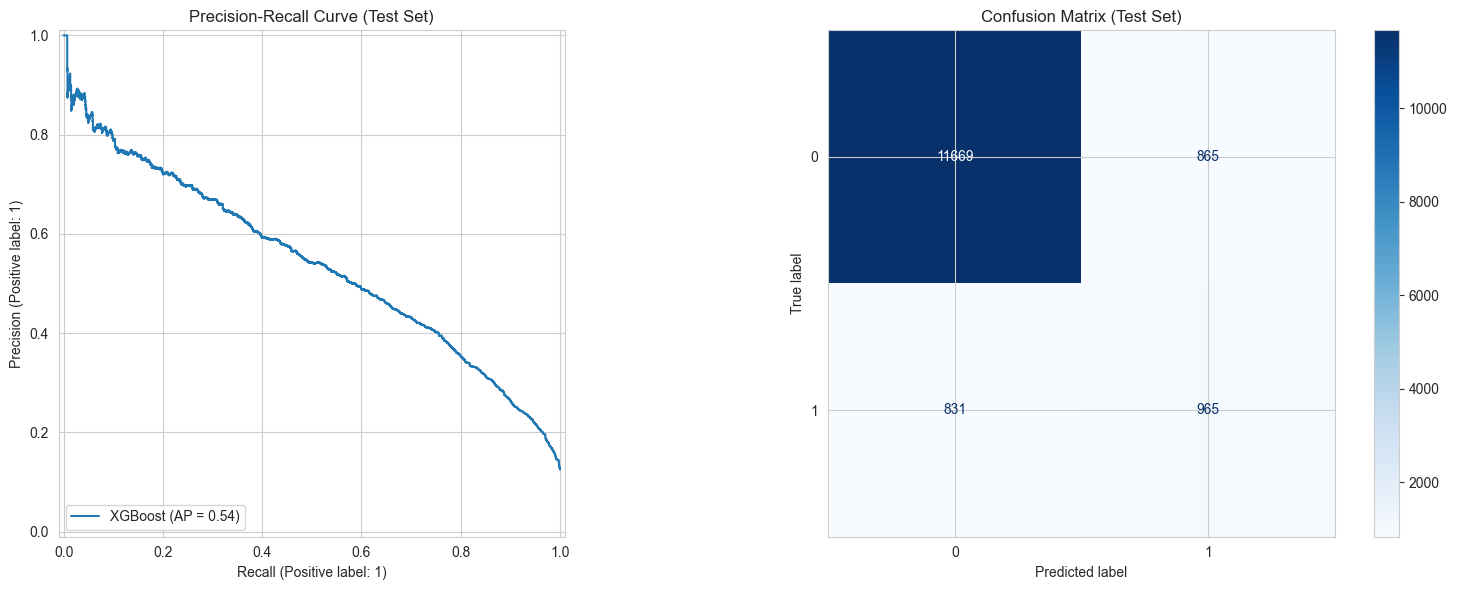

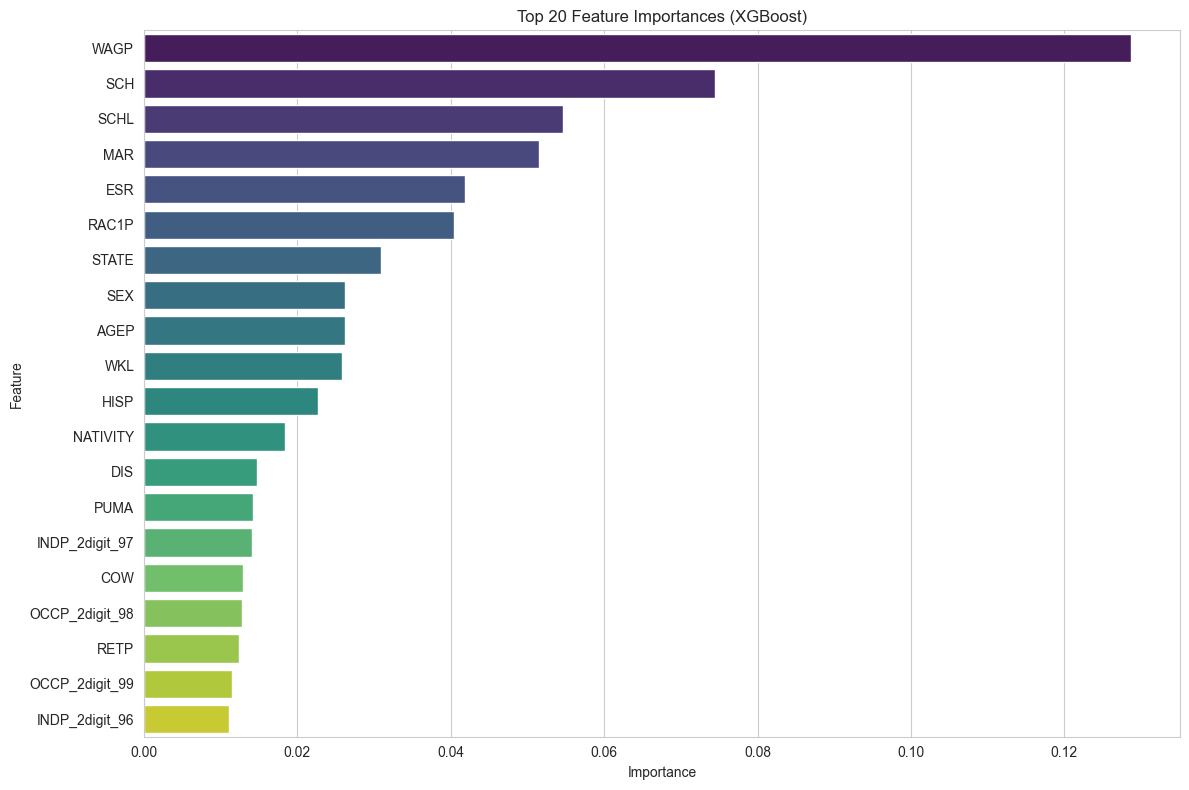

Best Model Selected: XGBoost on Statistical Set
Validation PR-AUC: 0.5006

--- Test Set Performance ---
Accuracy: 0.8816
ROC-AUC : 0.8743
PR-AUC  : 0.5416

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     12534
           1       0.53      0.54      0.53      1796

    accuracy                           0.88     14330
   macro avg       0.73      0.73      0.73     14330
weighted avg       0.88      0.88      0.88     14330



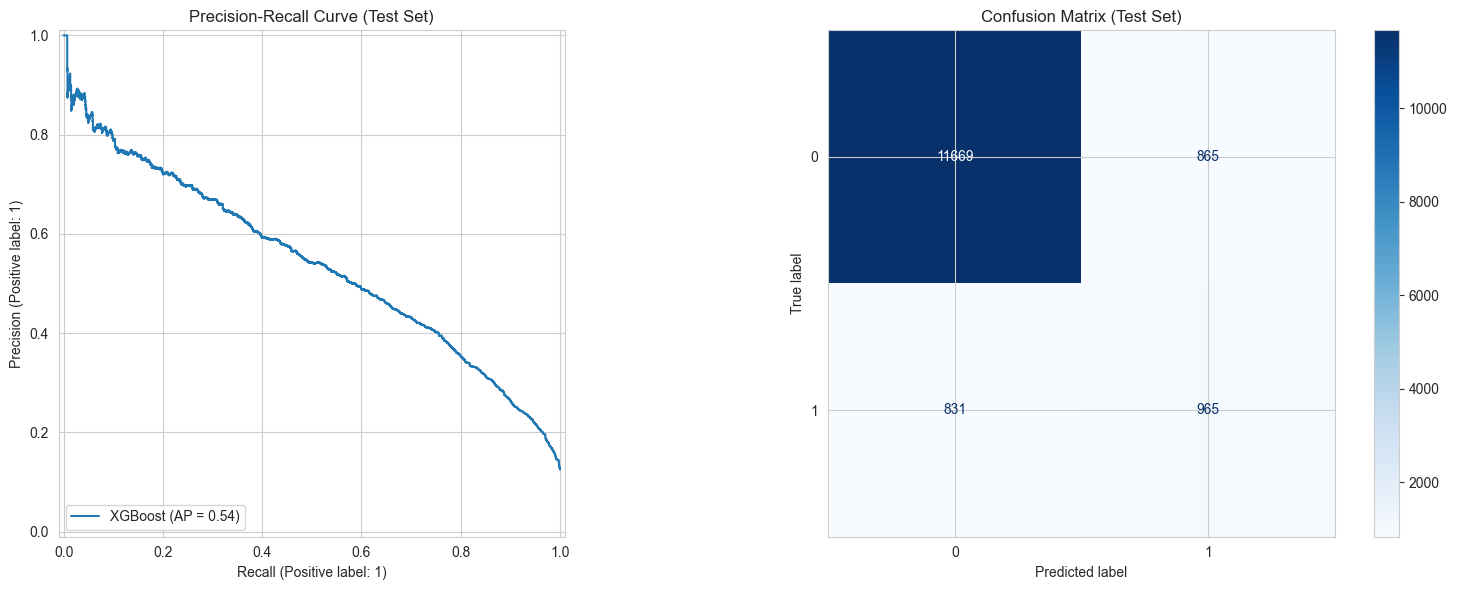

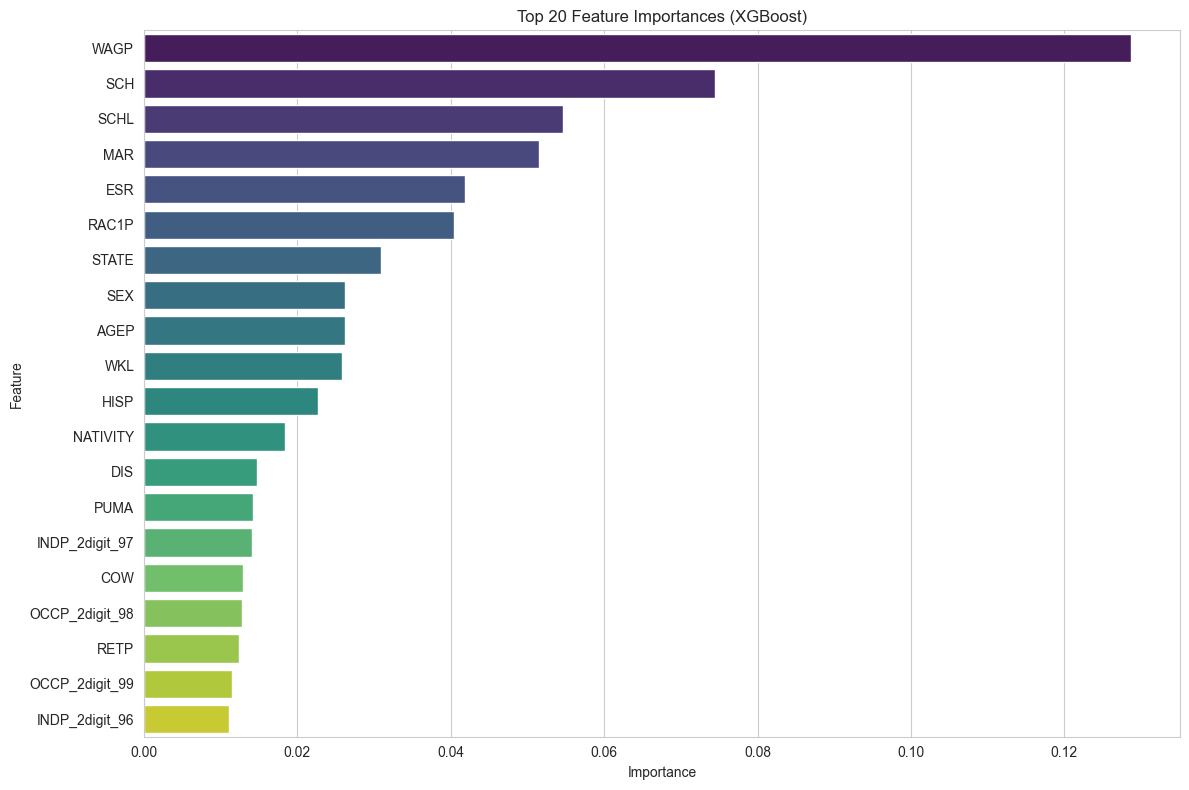

In [118]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

if not results_df.empty:
    # 1. Select Best Model (Fixing column name case sensitivity)
    best_row = results_df.sort_values('Val_PR_AUC', ascending=False).iloc[0]
    best_model_name = best_row['Model']
    best_dataset_name = best_row['Dataset']
    best_model_instance = best_row['Model_Instance']
    
    print(f"Best Model Selected: {best_model_name} on {best_dataset_name} Set")
    print(f"Validation PR-AUC: {best_row['Val_PR_AUC']:.4f}")
    
    # 2. Retrieve Test Data
    if best_dataset_name in data_splits:
        X_test = data_splits[best_dataset_name]['X_test']
        y_test = data_splits[best_dataset_name]['y_test']
        
        # 3. Predict on Test Set
        y_pred_test = best_model_instance.predict(X_test)
        y_prob_test = best_model_instance.predict_proba(X_test)[:, 1] if hasattr(best_model_instance, "predict_proba") else y_pred_test
        
        # 4. Calculate Metrics
        test_acc = accuracy_score(y_test, y_pred_test)
        test_roc = roc_auc_score(y_test, y_prob_test)
        test_pr = average_precision_score(y_test, y_prob_test)
        
        print(f"\n--- Test Set Performance ---")
        print(f"Accuracy: {test_acc:.4f}")
        print(f"ROC-AUC : {test_roc:.4f}")
        print(f"PR-AUC  : {test_pr:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred_test))
        
        # 5. Visualizations
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # --- CHANGED: Precision-Recall Curve ---
        PrecisionRecallDisplay.from_estimator(best_model_instance, X_test, y_test, ax=axes[0], name=f"{best_model_name}")
        axes[0].set_title("Precision-Recall Curve (Test Set)")
        # ---------------------------------------
        
        # Confusion Matrix
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues', ax=axes[1])
        axes[1].set_title("Confusion Matrix (Test Set)")
        
        plt.tight_layout()
        plt.show()
        
        # 6. Feature Importance (if applicable)
        if hasattr(best_model_instance, 'feature_importances_'):
            importances = best_model_instance.feature_importances_
            feature_names = X_test.columns
            
            # Create DataFrame
            fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            fi_df = fi_df.sort_values('Importance', ascending=False).head(20)
            
            plt.figure(figsize=(12, 8))
            sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
            plt.title(f'Top 20 Feature Importances ({best_model_name})')
            plt.tight_layout()
            plt.show()
            
    else:
        print(f"Errorfrom sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay")

if not results_df.empty:
    # 1. Select Best Model (Fixing column name case sensitivity)
    best_row = results_df.sort_values('Val_PR_AUC', ascending=False).iloc[0]
    best_model_name = best_row['Model']
    best_dataset_name = best_row['Dataset']
    best_model_instance = best_row['Model_Instance']
    
    print(f"Best Model Selected: {best_model_name} on {best_dataset_name} Set")
    print(f"Validation PR-AUC: {best_row['Val_PR_AUC']:.4f}")
    
    # 2. Retrieve Test Data
    if best_dataset_name in data_splits:
        X_test = data_splits[best_dataset_name]['X_test']
        y_test = data_splits[best_dataset_name]['y_test']
        
        # 3. Predict on Test Set
        y_pred_test = best_model_instance.predict(X_test)
        y_prob_test = best_model_instance.predict_proba(X_test)[:, 1] if hasattr(best_model_instance, "predict_proba") else y_pred_test
        
        # 4. Calculate Metrics
        test_acc = accuracy_score(y_test, y_pred_test)
        test_roc = roc_auc_score(y_test, y_prob_test)
        test_pr = average_precision_score(y_test, y_prob_test)
        
        print(f"\n--- Test Set Performance ---")
        print(f"Accuracy: {test_acc:.4f}")
        print(f"ROC-AUC : {test_roc:.4f}")
        print(f"PR-AUC  : {test_pr:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred_test))
        
        # 5. Visualizations
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # --- CHANGED: Precision-Recall Curve ---
        PrecisionRecallDisplay.from_estimator(best_model_instance, X_test, y_test, ax=axes[0], name=f"{best_model_name}")
        axes[0].set_title("Precision-Recall Curve (Test Set)")
        # ---------------------------------------
        
        # Confusion Matrix
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues', ax=axes[1])
        axes[1].set_title("Confusion Matrix (Test Set)")
        
        plt.tight_layout()
        plt.show()
        
        # 6. Feature Importance (if applicable)
        if hasattr(best_model_instance, 'feature_importances_'):
            importances = best_model_instance.feature_importances_
            feature_names = X_test.columns
            
            # Create DataFrame
            fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            fi_df = fi_df.sort_values('Importance', ascending=False).head(20)
            
            plt.figure(figsize=(12, 8))
            sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
            plt.title(f'Top 20 Feature Importances ({best_model_name})')
            plt.tight_layout()
            plt.show()
            
    else:
        print(f"Error")

---

# 5. Fairness

In [1]:
# =====  FAIRNESS ASSESSMENT  =====

# Make sure these imports are present at the top of your notebook / script
from fairlearn.metrics import (
    MetricFrame,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference,
)

# 1. Pick the best model according to validation ROC-AUC
best_row = results_df.iloc[0]
best_model = best_row['best_model_instance']
best_model_name = best_row['Model']
best_dataset_name = best_row['Dataset']

print(f"\nBest model (by Val_ROC_AUC): {best_model_name} on {best_dataset_name}")

# 2. Get the corresponding test split
splits = data_splits[best_dataset_name]
X_test = splits['X_test']
y_test = splits['y_test']

# 3. Choose a sensitive attribute from the ORIGINAL df_2_3
#    You can switch this to 'SEX', 'age_group', 'HISP', 'RAC1P', etc.
sensitive_attr_name = 'RAC1P'   # <--- change this if you want another attribute
sensitive_series = df_2_3.loc[X_test.index, sensitive_attr_name]

# 4. Predictions from the best model
y_pred = best_model.predict(X_test)
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:, 1]
else:
    y_prob = y_pred  # Fallback (not used in fairness metrics, but kept for completeness)

# 5. MetricFrame: selection rate, TPR, FPR by group
metrics = MetricFrame(
    metrics={
        "selection_rate": selection_rate,       # P(Ŷ=1 | A=a)
        "TPR": true_positive_rate,             # P(Ŷ=1 | Y=1, A=a)
        "FPR": false_positive_rate,            # P(Ŷ=1 | Y=0, A=a)
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_series,
)

metrics_df = metrics.by_group.copy()

# 5b. Actual distribution in the data (base rate P(Y=1 | A=a) on the TEST set)
# We restrict to the test indices to be consistent with fairness metrics
test_subset = df_2_3.loc[X_test.index, [sensitive_attr_name, 'only_medicaid']]

group_stats = (
    test_subset
    .groupby(sensitive_attr_name)['only_medicaid']
    .agg(
        base_rate='mean',   # P(Y=1 | A=a)
        count='size',       # number of samples in group
        positives='sum'     # number of Y=1 in group
    )
)

# 5c. Combine fairness metrics with base rates
combined = metrics_df.join(group_stats)

# Optional: convert key rates to percentages for easier interpretation
combined_pct = combined.copy()
for col in ['selection_rate', 'TPR', 'base_rate']:
    combined_pct[col] = (combined_pct[col] * 100).round(2)

print("\n=== Fairness metrics vs. actual label distribution (test set) ===")
print(combined_pct[['count', 'positives', 'base_rate', 'selection_rate', 'TPR', 'FPR']])

# 6. Demographic parity difference:
#    max_a,b | P(Ŷ=1 | A=a) - P(Ŷ=1 | A=b) |
dpd = demographic_parity_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_series
)
print(f"\nDemographic Parity Difference ({sensitive_attr_name}): {dpd:.3f}")

# 7. Equalized odds difference:
#    max difference in TPR/FPR across groups
eod = equalized_odds_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_series
)
print(f"Equalized Odds Difference ({sensitive_attr_name}): {eod:.3f}")

NameError: name 'results_df' is not defined